# nanonis_reader 리팩터링 테스트
## 새 API (`sts`, `iz`) + deprecated 래퍼 검증

### 테스트 항목
1. **새 API** (`d.sts`, `d.iz`) 동작 + 시각화
2. **Deprecated 래퍼** 하위 호환 + 수치 동일성
3. **`normalize_didv` 독립 함수** 검증
4. **Topography** 이미지 처리 확인

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import nanonis_reader as nr
from nanonis_reader.cmap_custom import nanox, bwr

%matplotlib inline
plt.rcParams['font.family'] = 'arial'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['ytick.minor.width'] = 0.5
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = [86.0/25.4, 86.0/25.4]

print(f'nanonis_reader loaded from: {nr.__file__}')
print(f'normalize_didv available: {hasattr(nr, "normalize_didv")}')

nanonis_reader loaded from: /Users/kim/Documents/git_clones/nanonis_reader/nanonis_reader/__init__.py
normalize_didv available: True


---
## 0. 데이터 로드

In [2]:
# ===== 여기에 .3ds 파일 경로를 입력하세요 =====
GRID_FILE = '/Users/kim/Library/CloudStorage/OneDrive-Personal/Data/230922_TNS_STM6/TNS_STM6_#117_5495.3ds'
# =============================================

d = nr.load(GRID_FILE)
print(f'File: {d.fname}')
print(f'dim_px: {d.header["dim_px"]}  (pixels_x, pixels_y)')
print(f'Signal keys: {list(d.signals.keys())[:8]}...')
print(f'Bias points: {len(d.sts.sweep_signal)}')
print(f'Bias range: {d.sts.sweep_signal[0]:.3f} ~ {d.sts.sweep_signal[-1]:.3f} V')

File: TNS_STM6_#117_5495.3ds
dim_px: [30, 60]  (pixels_x, pixels_y)
Signal keys: ['params', 'Current (A)', 'Z (m)', 'LI Demod 1 X (A)', 'LI Demod 2 X (A)', 'sweep_signal', 'topo']...
Bias points: 141
Bias range: 0.700 ~ -0.700 V


---
## 1. 새 API: `d.sts` — 스펙트럼 + 맵

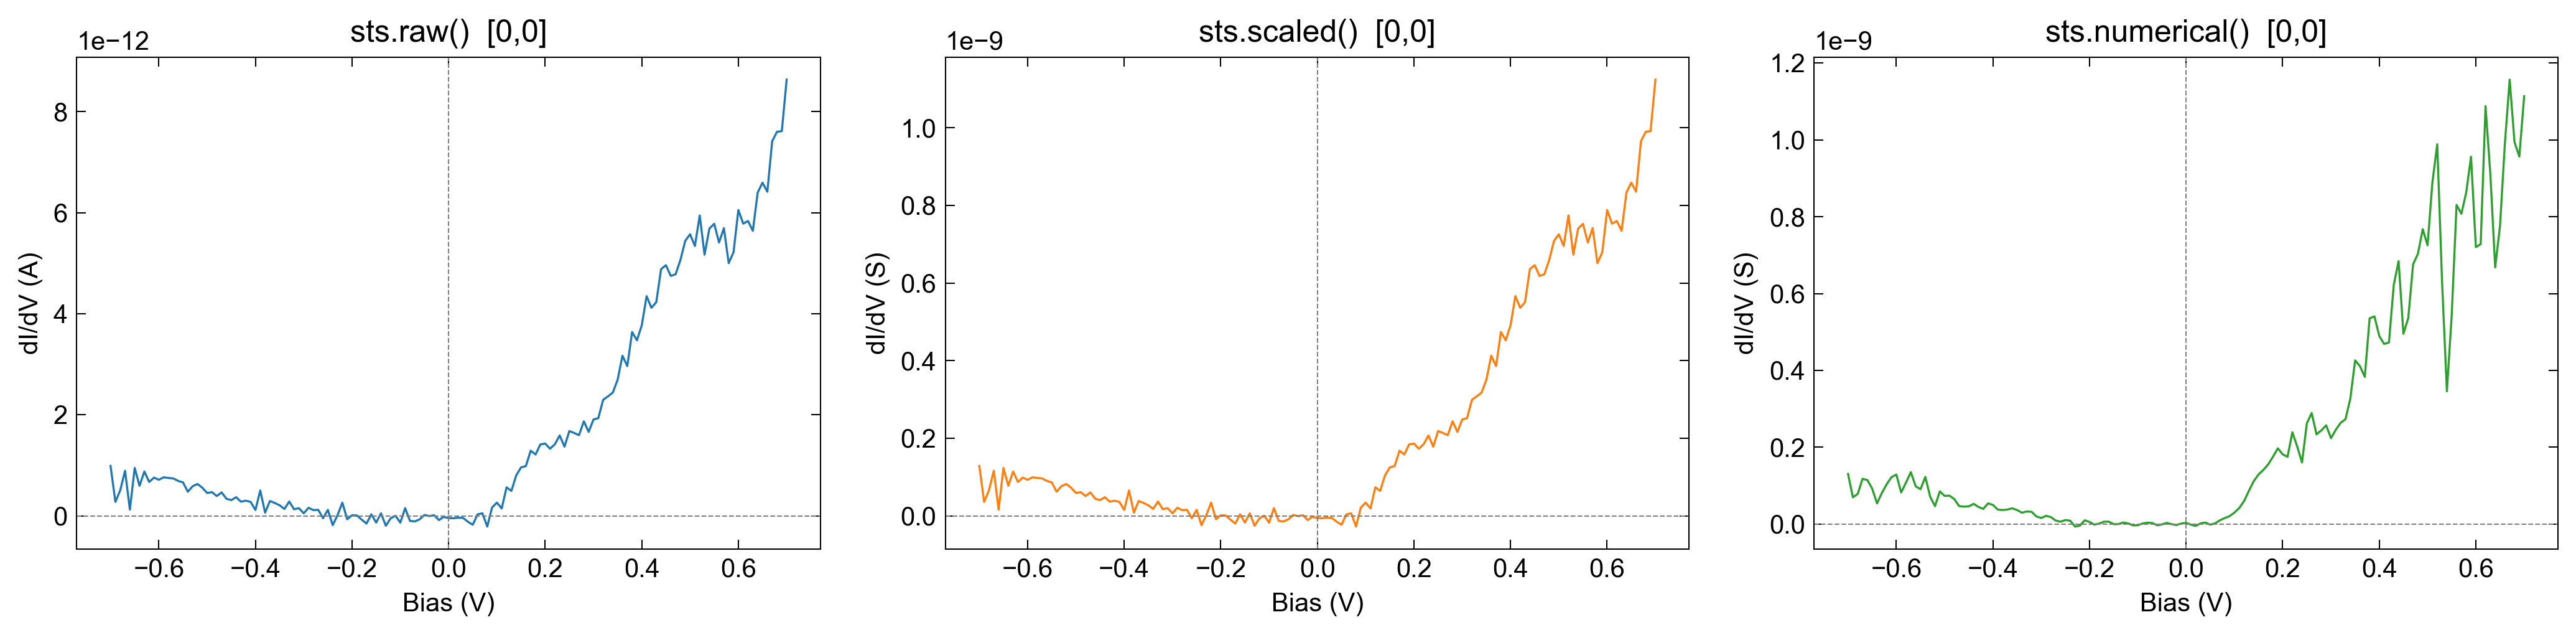

3D shapes — raw: (60, 30, 141), scaled: (60, 30, 141), numerical: (60, 30, 141)


In [3]:
# 1.1 raw / scaled / numerical — 포인트 스펙트럼 비교
line, pixel = 0, 0

V_raw, raw_3d = d.sts.raw()
V_sc, sc_3d = d.sts.scaled()
V_num, num_3d = d.sts.numerical()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

axes[0].plot(V_raw, raw_3d[line, pixel], lw=0.8)
axes[0].set_title(f'sts.raw()  [{line},{pixel}]')
axes[0].set_xlabel('Bias (V)')
axes[0].set_ylabel('dI/dV (A)')

axes[1].plot(V_sc, sc_3d[line, pixel], lw=0.8, color='C1')
axes[1].set_title(f'sts.scaled()  [{line},{pixel}]')
axes[1].set_xlabel('Bias (V)')
axes[1].set_ylabel('dI/dV (S)')

axes[2].plot(V_num, num_3d[line, pixel], lw=0.8, color='C2')
axes[2].set_title(f'sts.numerical()  [{line},{pixel}]')
axes[2].set_xlabel('Bias (V)')
axes[2].set_ylabel('dI/dV (S)')

for ax in axes:
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.axvline(0, color='gray', lw=0.5, ls='--')
plt.tight_layout()
plt.show()

print(f'3D shapes — raw: {raw_3d.shape}, scaled: {sc_3d.shape}, numerical: {num_3d.shape}')

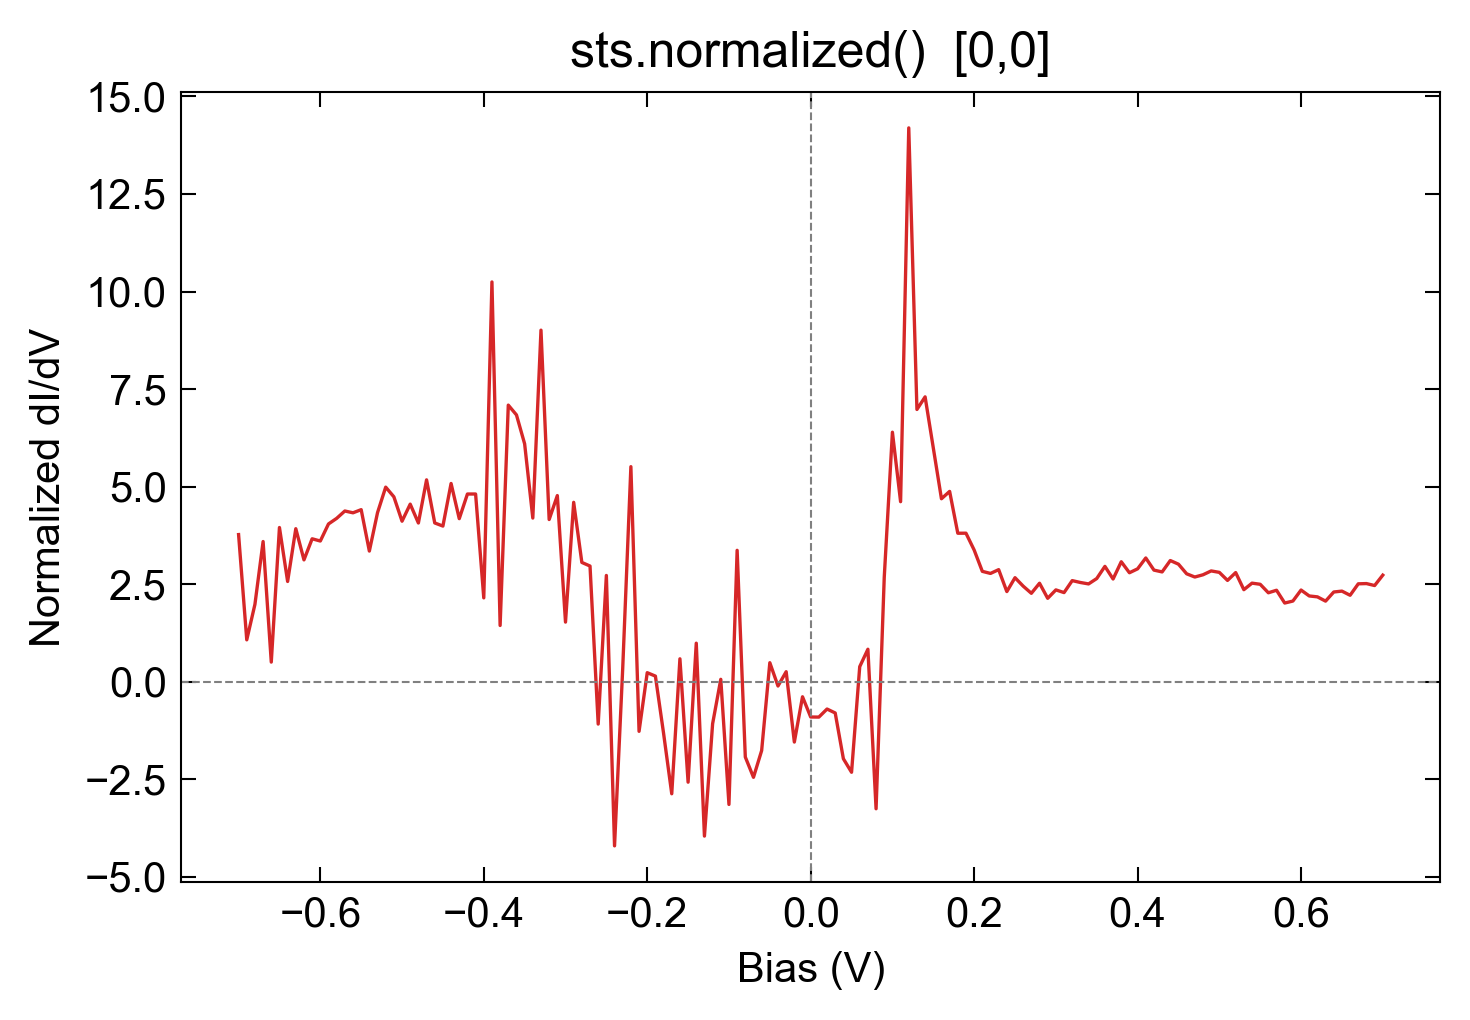

normalized shape: (60, 30, 141)  (bias reduced by 1: 141 → 141)


In [4]:
# 1.2 normalized — 포인트 스펙트럼
V_norm, norm_3d = d.sts.normalized(factor=0.2, delete_zero_bias=False)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(V_norm, norm_3d[line, pixel], lw=0.8, color='C3')
ax.set_title(f'sts.normalized()  [{line},{pixel}]')
ax.set_xlabel('Bias (V)')
ax.set_ylabel('Normalized dI/dV')
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvline(0, color='gray', lw=0.5, ls='--')
plt.tight_layout()
plt.show()

print(f'normalized shape: {norm_3d.shape}  (bias reduced by 1: {len(d.sts.sweep_signal)} → {norm_3d.shape[2]})')

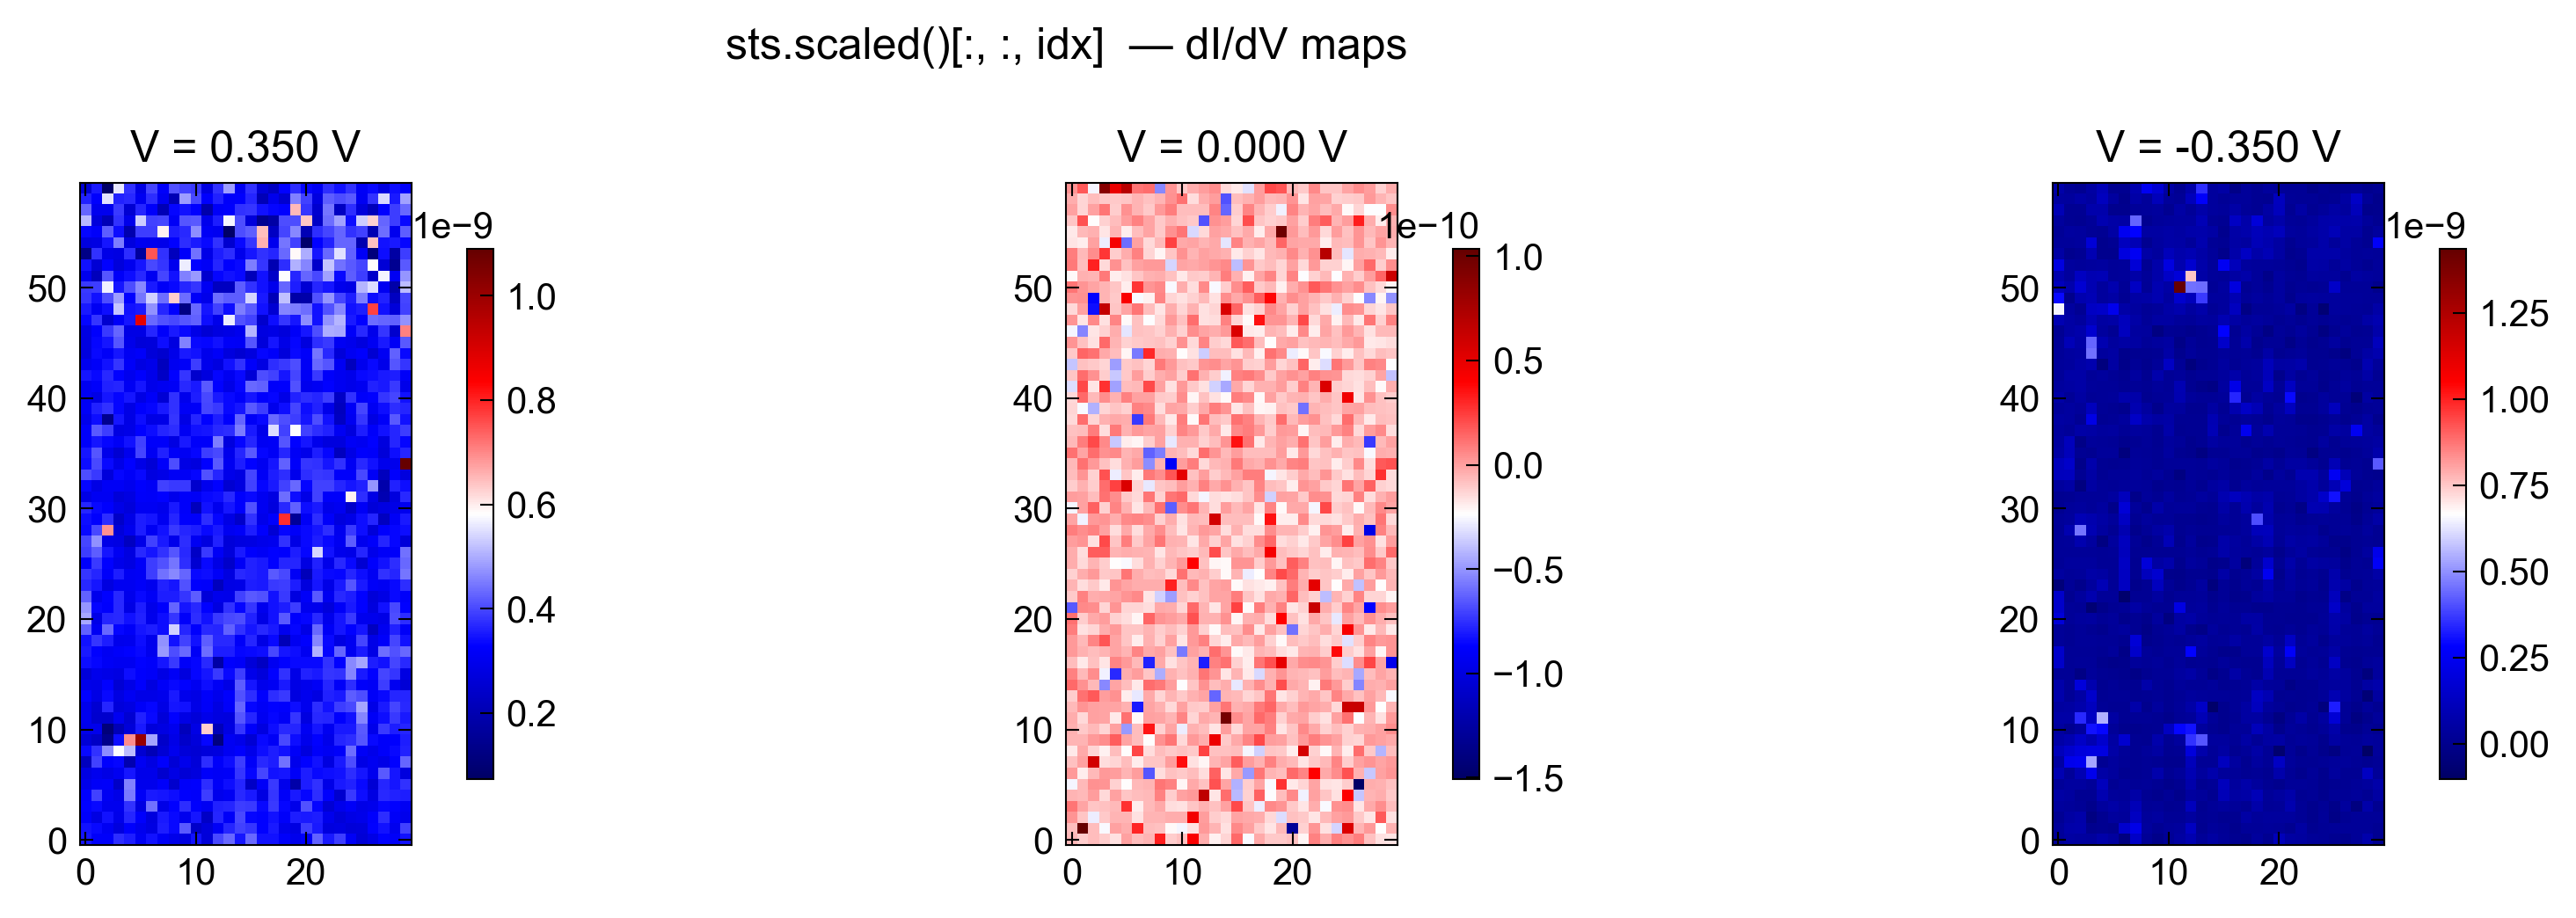

In [5]:
# 1.3 scaled — dI/dV 맵 (특정 bias에서의 2D 슬라이스)
V, sc_3d = d.sts.scaled()
n_bias = len(V)
indices = [n_bias//4, n_bias//2, 3*n_bias//4]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, idx in zip(axes, indices):
    im = ax.imshow(sc_3d[:, :, idx], cmap=bwr(), origin='lower')
    ax.set_title(f'V = {V[idx]:.3f} V')
    plt.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle('sts.scaled()[:, :, idx]  — dI/dV maps', fontsize=12)
plt.tight_layout()
plt.show()

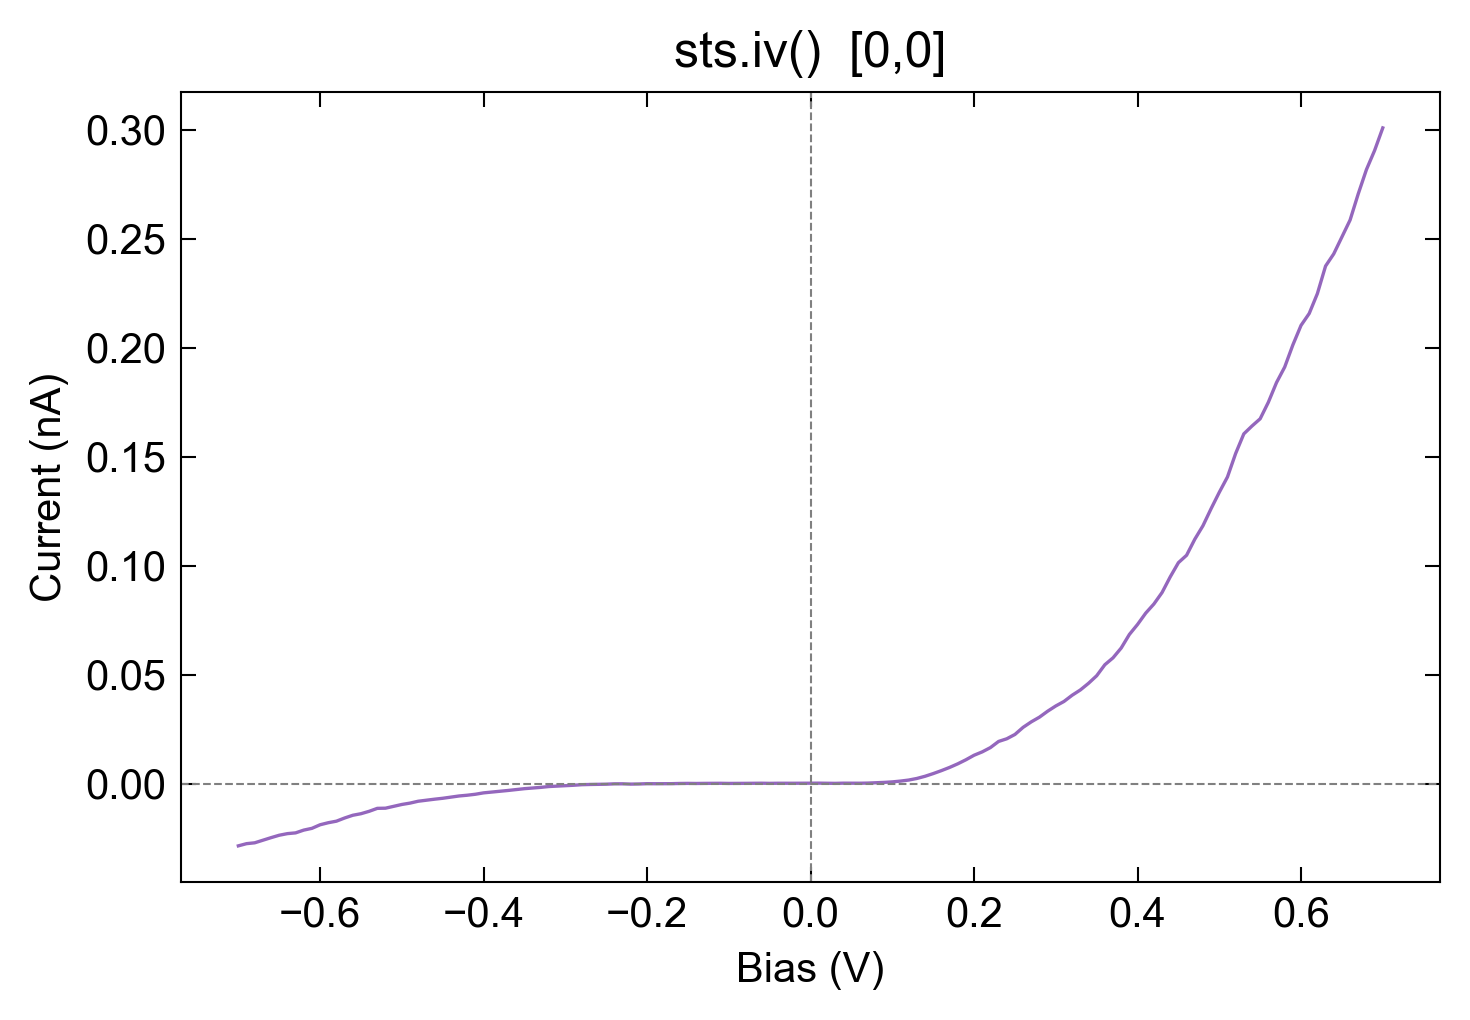

In [6]:
# 1.4 I-V 커브
V_iv, iv_3d = d.sts.iv()

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(V_iv, iv_3d[line, pixel] * 1e9, lw=0.8, color='C4')
ax.set_title(f'sts.iv()  [{line},{pixel}]')
ax.set_xlabel('Bias (V)')
ax.set_ylabel('Current (nA)')
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvline(0, color='gray', lw=0.5, ls='--')
plt.tight_layout()
plt.show()

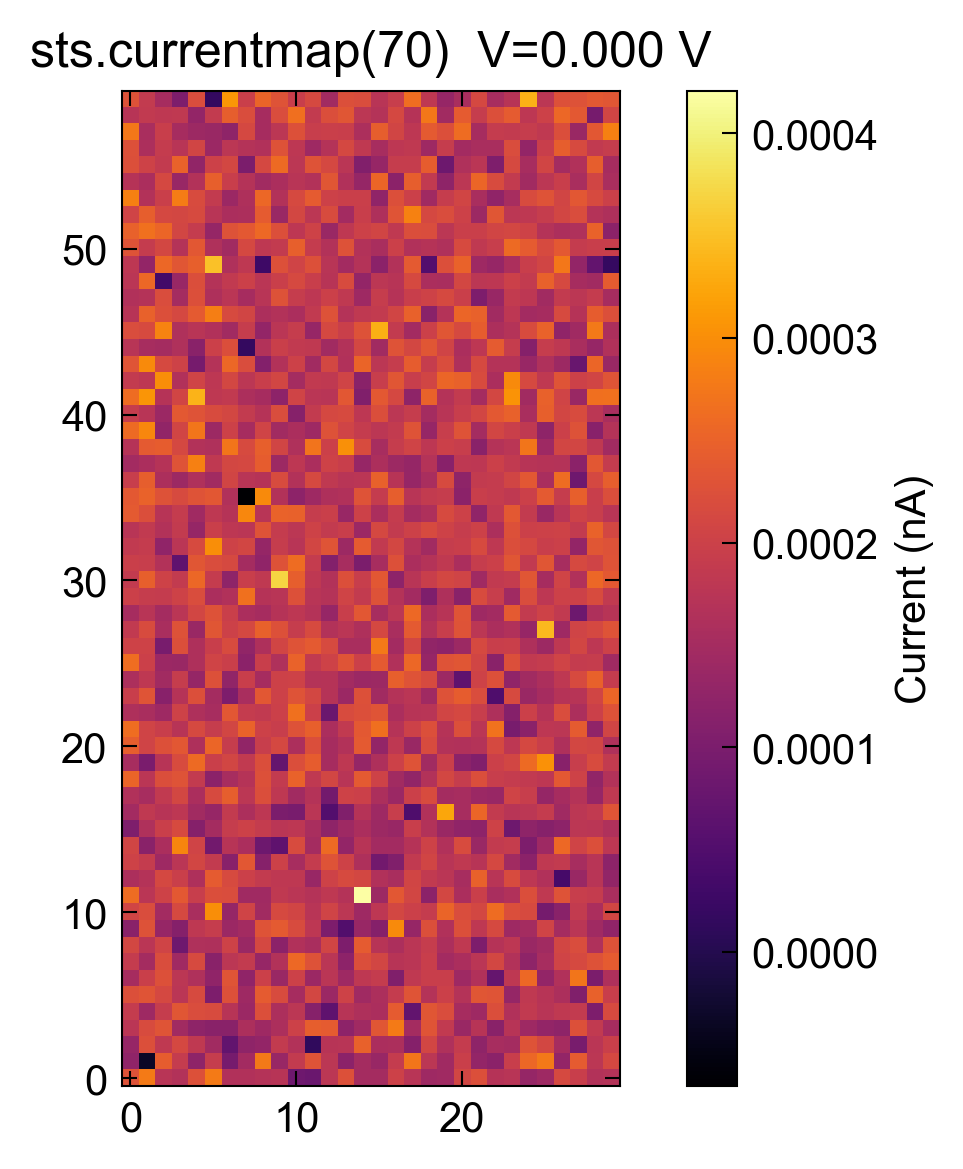

In [7]:
# 1.5 currentmap
mid_idx = len(d.sts.sweep_signal) // 2
cmap_data = d.sts.currentmap(mid_idx)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cmap_data * 1e9, cmap='inferno', origin='lower')
ax.set_title(f'sts.currentmap({mid_idx})  V={d.sts.sweep_signal[mid_idx]:.3f} V')
plt.colorbar(im, ax=ax, label='Current (nA)')
plt.tight_layout()
plt.show()

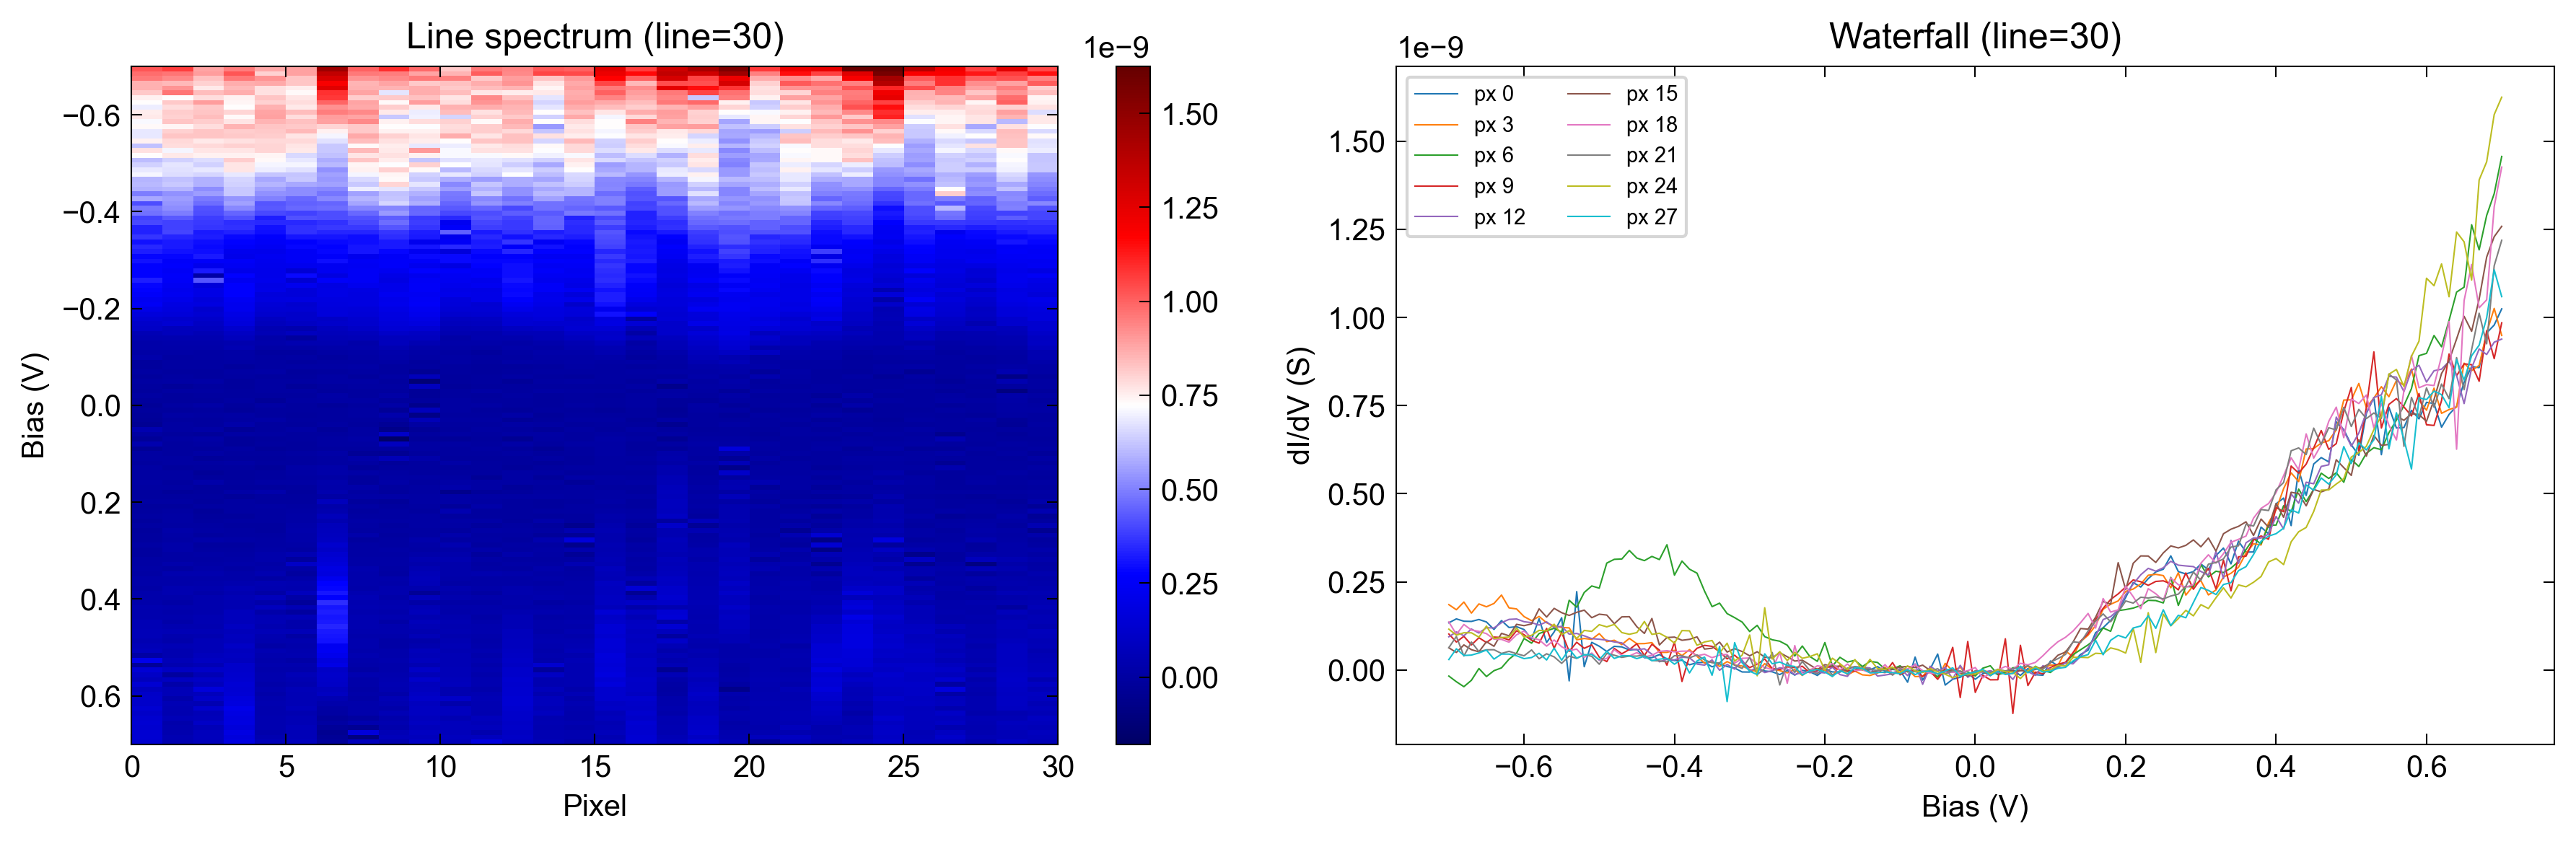

In [8]:
# 1.6 라인 스펙트럼 (waterfall / heatmap)
V, sc_3d = d.sts.scaled()
line_idx = sc_3d.shape[0] // 2  # 중간 라인
line_data = sc_3d[line_idx]  # (pixels, bias)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Heatmap
im = axes[0].imshow(line_data.T, aspect='auto', origin='upper',
                     extent=[0, line_data.shape[0], V[0], V[-1]], cmap=bwr())
axes[0].set_xlabel('Pixel')
axes[0].set_ylabel('Bias (V)')
axes[0].set_title(f'Line spectrum (line={line_idx})')
plt.colorbar(im, ax=axes[0])

# Waterfall (every 5th pixel)
step = max(1, line_data.shape[0] // 10)
for i in range(0, line_data.shape[0], step):
    axes[1].plot(V, line_data[i], lw=0.5, label=f'px {i}')
axes[1].set_xlabel('Bias (V)')
axes[1].set_ylabel('dI/dV (S)')
axes[1].set_title(f'Waterfall (line={line_idx})')
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

---
## 2. Topography

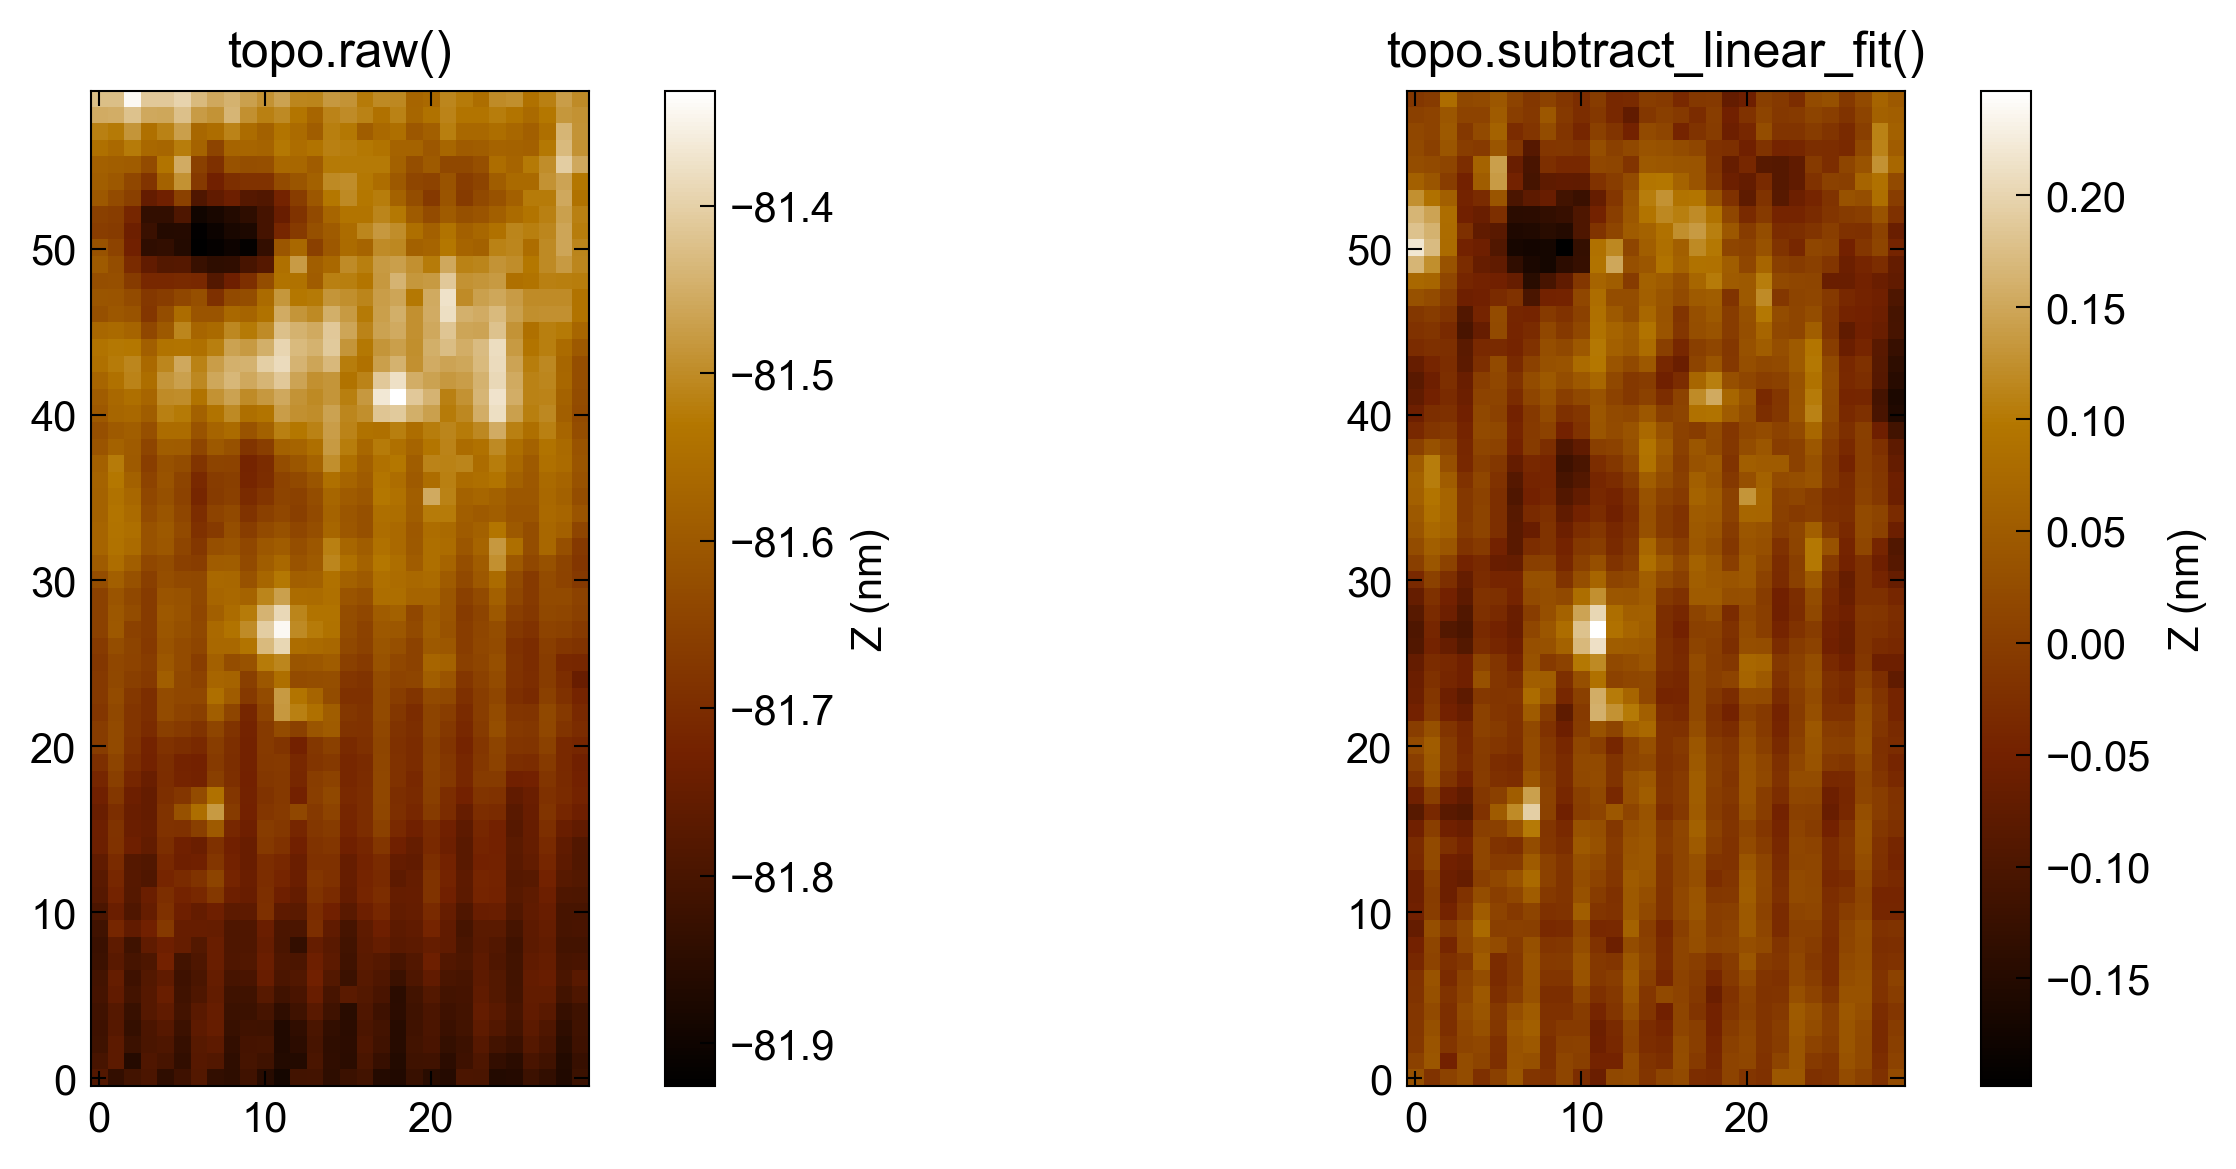

In [9]:
topo_raw = d.topo.raw()
topo_lf = d.topo.subtract_linear_fit()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(topo_raw * 1e9, cmap=nanox(), origin='lower')
axes[0].set_title('topo.raw()')
plt.colorbar(im0, ax=axes[0], label='Z (nm)')

im1 = axes[1].imshow(topo_lf * 1e9, cmap=nanox(), origin='lower')
axes[1].set_title('topo.subtract_linear_fit()')
plt.colorbar(im1, ax=axes[1], label='Z (nm)')

plt.tight_layout()
plt.show()

---
## 3. Deprecated 래퍼 — 수치 동일성 + 그래프 비교

/var/folders/nd/8bdpjnh50b744xww9jh6f5r80000gn/T/ipykernel_64547/3709409009.py:29: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/opt/miniconda3/envs/stm/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


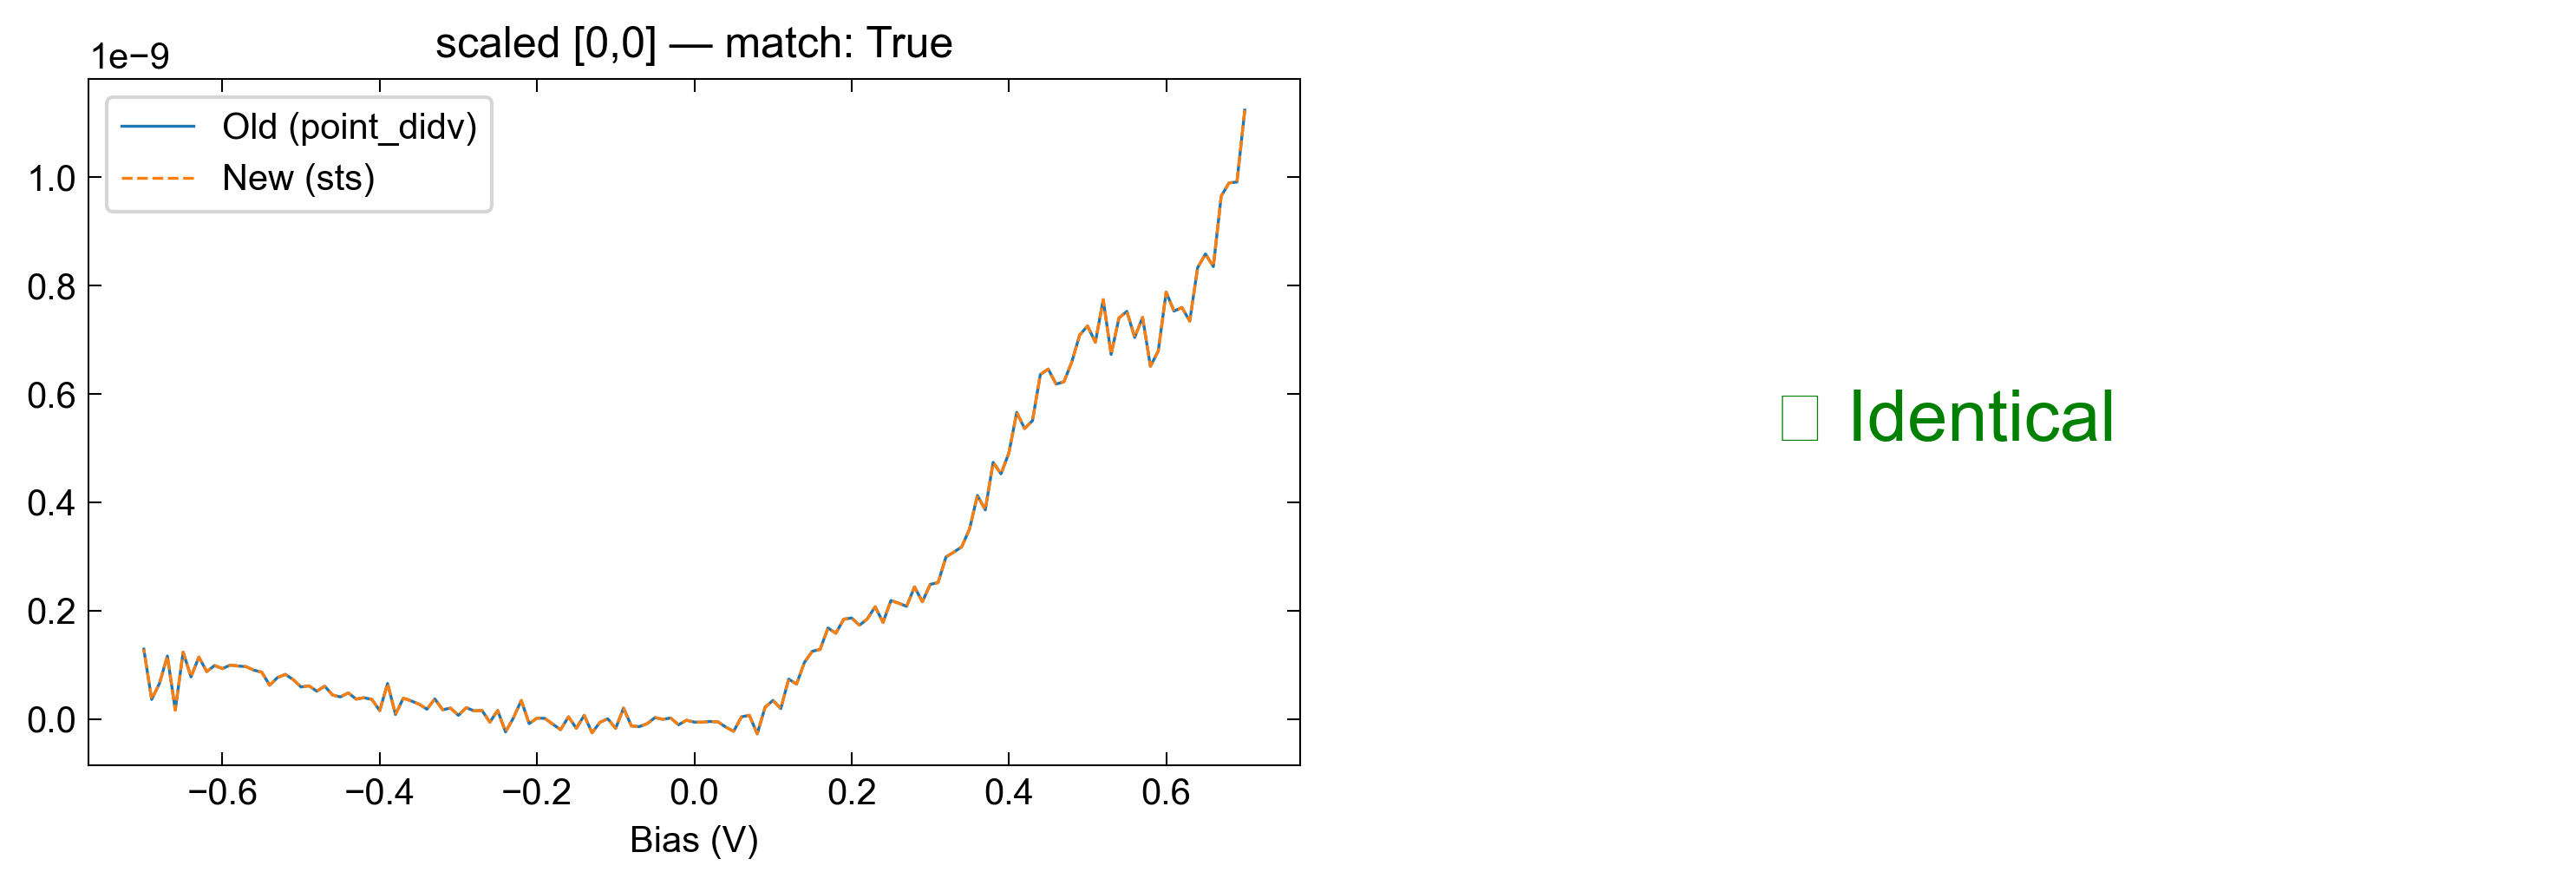

In [10]:
# 3.1 point_didv.get_didv_scaled vs sts.scaled slicing
line, pixel = 0, 0

with warnings.catch_warnings():
    warnings.simplefilter('ignore', DeprecationWarning)
    V_old, didv_old = nr.grid.point_didv(d).get_didv_scaled(line, pixel)

V_new, didv_3d = d.sts.scaled()
didv_new = didv_3d[line, pixel]

match = np.allclose(didv_old, didv_new, equal_nan=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(V_old, didv_old, lw=0.8, label='Old (point_didv)')
axes[0].plot(V_new, didv_new, lw=0.8, ls='--', label='New (sts)')
axes[0].legend()
axes[0].set_title(f'scaled [{line},{pixel}] — match: {match}')
axes[0].set_xlabel('Bias (V)')

if not match:
    axes[1].plot(V_old, np.abs(didv_old - didv_new), lw=0.8, color='red')
    axes[1].set_title('|Difference|')
    axes[1].set_xlabel('Bias (V)')
else:
    axes[1].text(0.5, 0.5, '✅ Identical', transform=axes[1].transAxes, 
                ha='center', va='center', fontsize=20, color='green')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

/var/folders/nd/8bdpjnh50b744xww9jh6f5r80000gn/T/ipykernel_64547/1880577363.py:31: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/opt/miniconda3/envs/stm/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


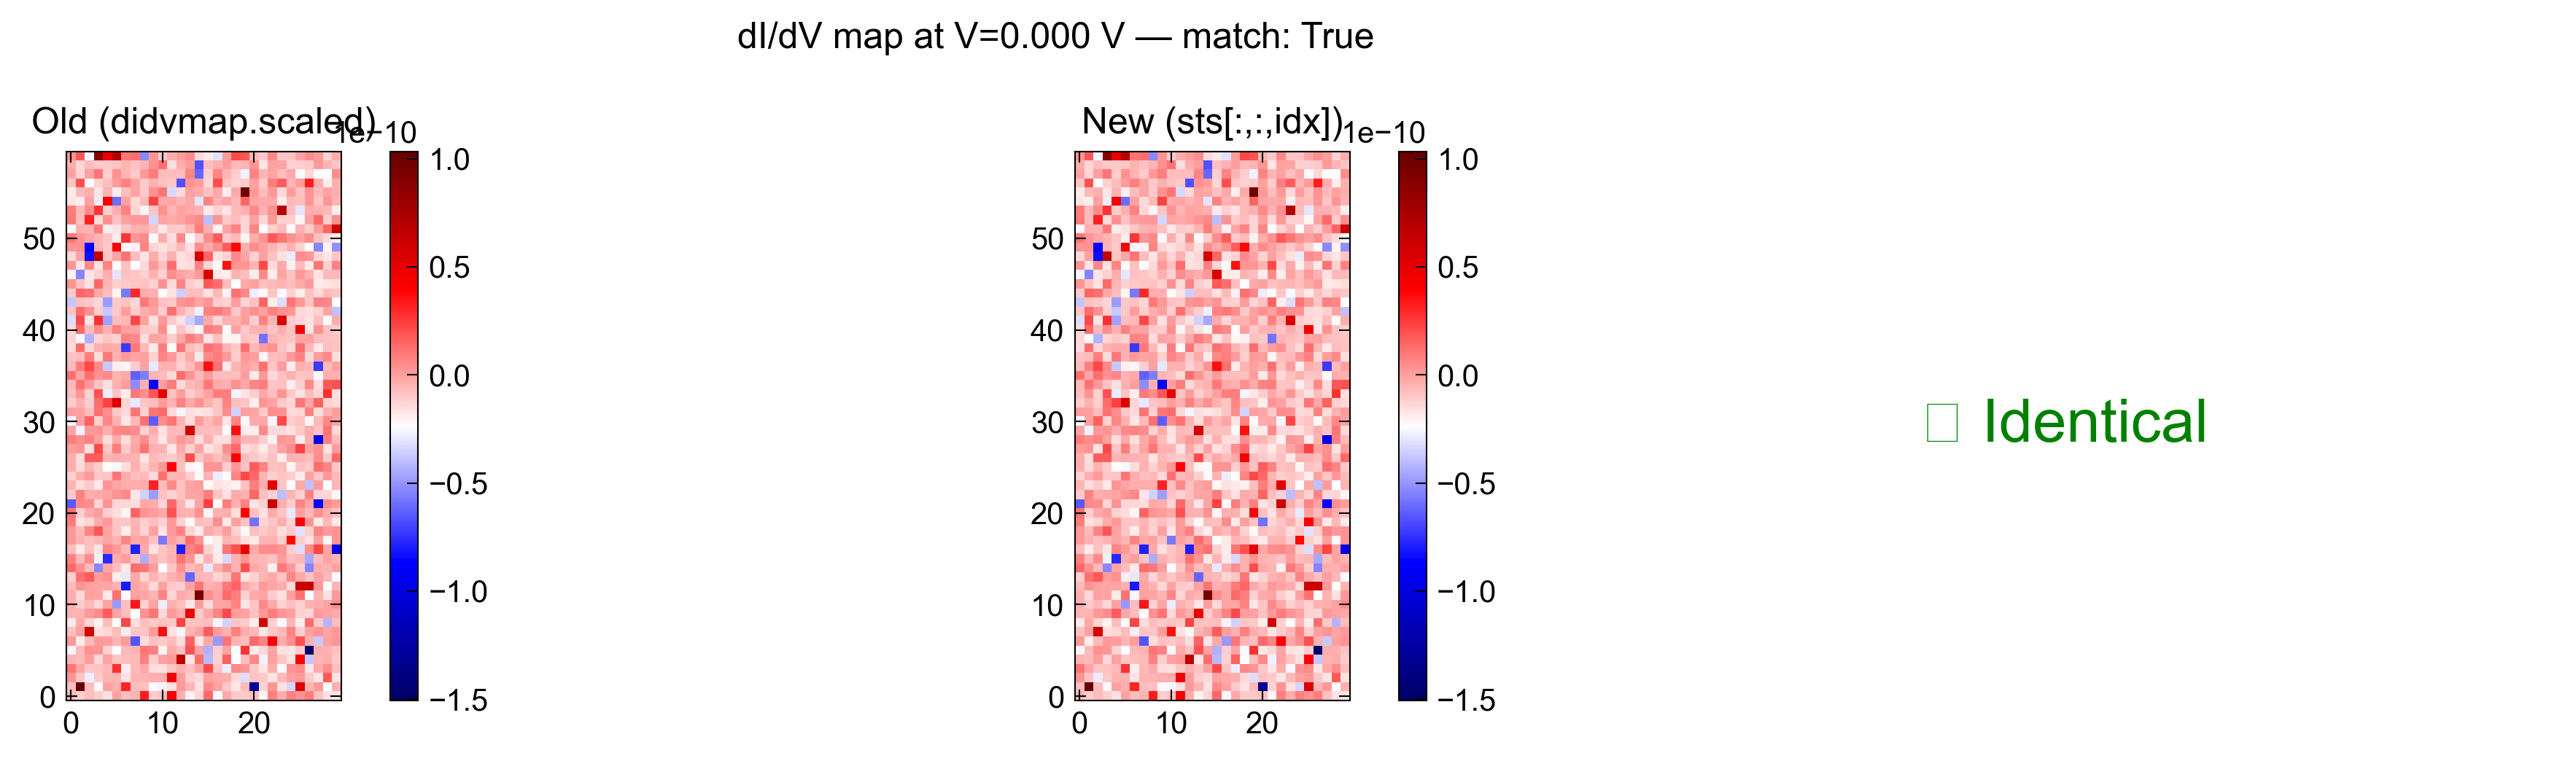

In [11]:
# 3.2 didvmap.scaled vs sts.scaled slicing (맵)
sweep_idx = len(d.sts.sweep_signal) // 2

with warnings.catch_warnings():
    warnings.simplefilter('ignore', DeprecationWarning)
    map_old = nr.grid.didvmap(d).scaled(sweep_idx)

V_new, data_3d = d.sts.scaled()
map_new = data_3d[:, :, sweep_idx]
match = np.allclose(map_old, map_new, equal_nan=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
im0 = axes[0].imshow(map_old, cmap=bwr(), origin='lower')
axes[0].set_title('Old (didvmap.scaled)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(map_new, cmap=bwr(), origin='lower')
axes[1].set_title('New (sts[:,:,idx])')
plt.colorbar(im1, ax=axes[1])

if not match:
    im2 = axes[2].imshow(np.abs(map_old - map_new), cmap='hot', origin='lower')
    axes[2].set_title('|Difference|')
    plt.colorbar(im2, ax=axes[2])
else:
    axes[2].text(0.5, 0.5, '✅ Identical', transform=axes[2].transAxes,
                ha='center', va='center', fontsize=20, color='green')
    axes[2].set_axis_off()

fig.suptitle(f'dI/dV map at V={V_new[sweep_idx]:.3f} V — match: {match}', fontsize=12)
plt.tight_layout()
plt.show()

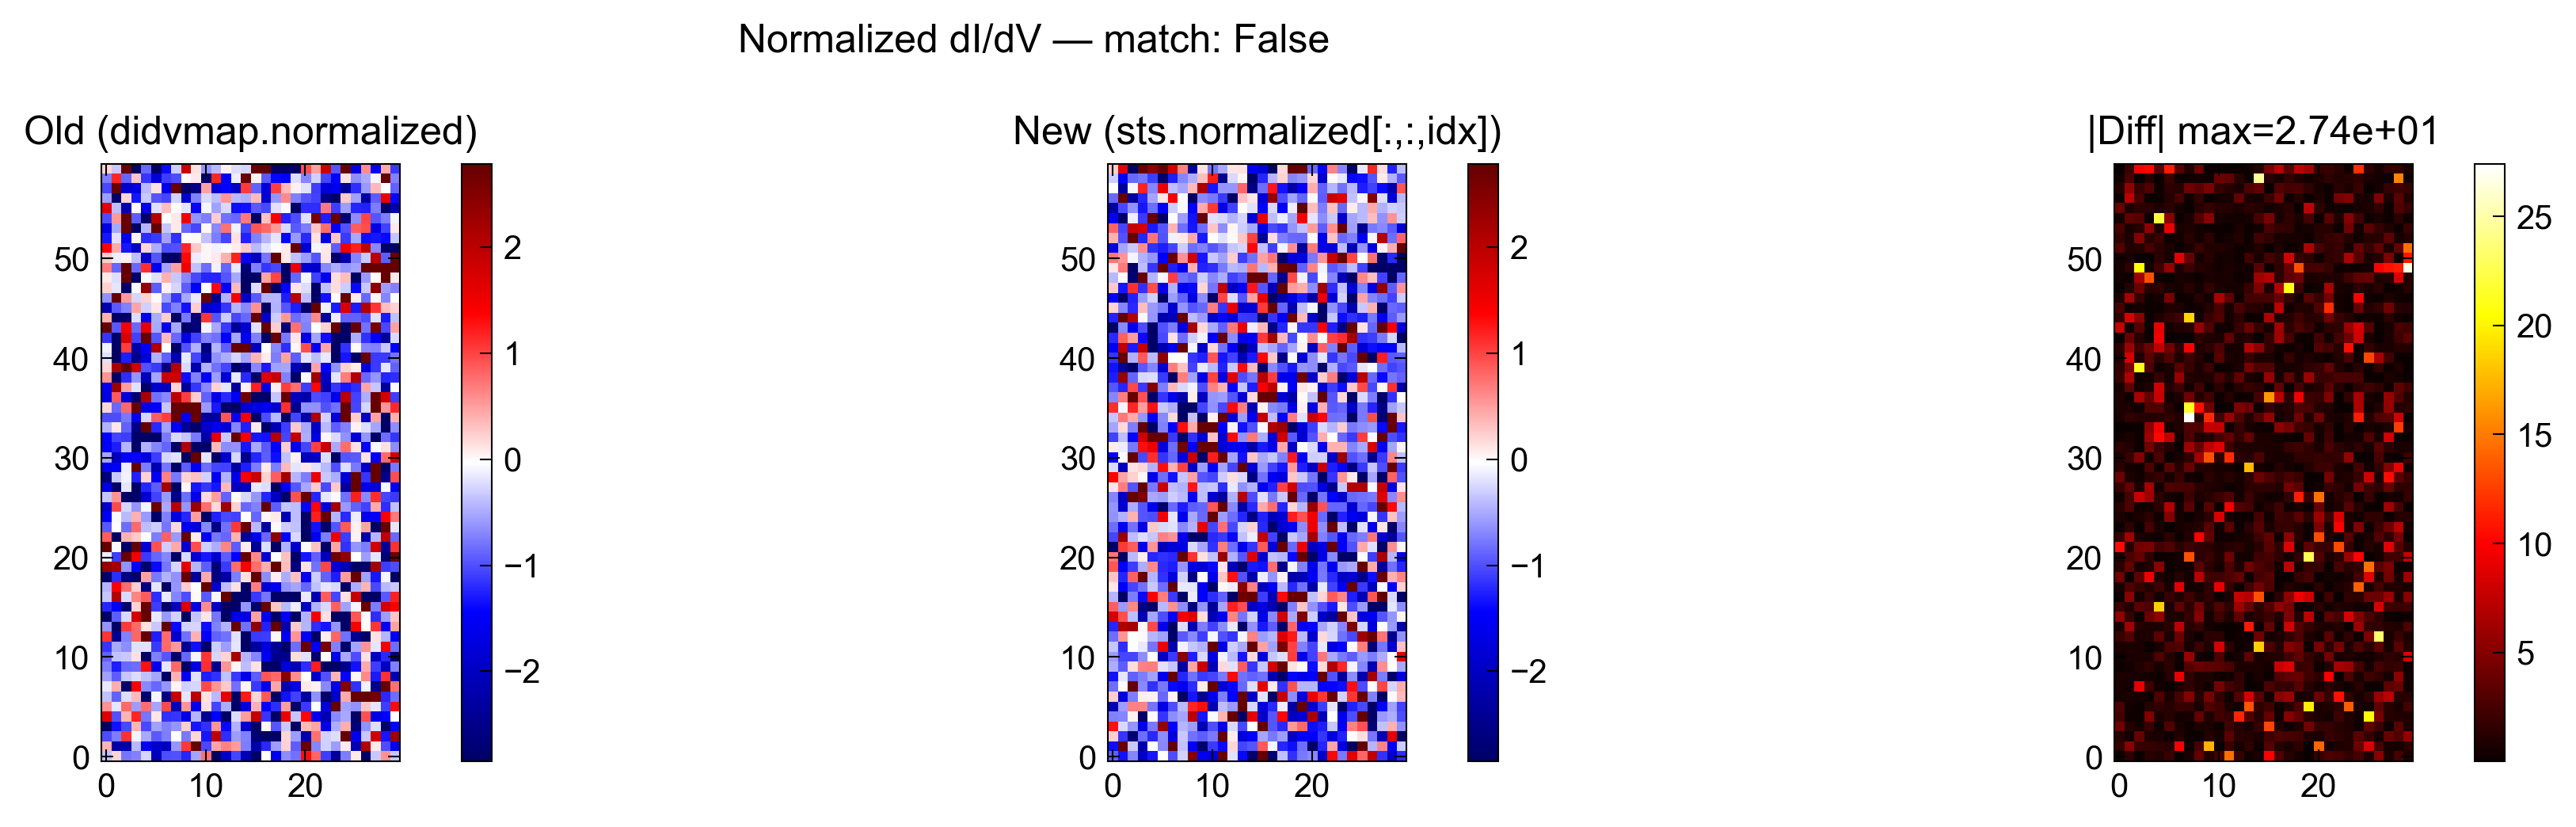

In [12]:
# 3.3 didvmap.normalized vs sts.normalized slicing
sweep_idx = len(d.sts.sweep_signal) // 2

with warnings.catch_warnings():
    warnings.simplefilter('ignore', DeprecationWarning)
    norm_old = nr.grid.didvmap(d).normalized(sweep_idx, factor=0.2)

V_norm, norm_3d = d.sts.normalized(factor=0.2)
norm_new = norm_3d[:, :, sweep_idx]
match = np.allclose(norm_old, norm_new, equal_nan=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
vmin = np.nanpercentile(norm_new, 5)
vmax = np.nanpercentile(norm_new, 95)

im0 = axes[0].imshow(norm_old, cmap=bwr(), origin='lower', vmin=vmin, vmax=vmax)
axes[0].set_title('Old (didvmap.normalized)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(norm_new, cmap=bwr(), origin='lower', vmin=vmin, vmax=vmax)
axes[1].set_title('New (sts.normalized[:,:,idx])')
plt.colorbar(im1, ax=axes[1])

if not match:
    diff = np.abs(norm_old - norm_new)
    im2 = axes[2].imshow(diff, cmap='hot', origin='lower')
    axes[2].set_title(f'|Diff| max={np.nanmax(diff):.2e}')
    plt.colorbar(im2, ax=axes[2])
else:
    axes[2].text(0.5, 0.5, '✅ Identical', transform=axes[2].transAxes,
                ha='center', va='center', fontsize=20, color='green')
    axes[2].set_axis_off()

fig.suptitle(f'Normalized dI/dV — match: {match}', fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/nd/8bdpjnh50b744xww9jh6f5r80000gn/T/ipykernel_64547/1968985493.py:36: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/opt/miniconda3/envs/stm/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


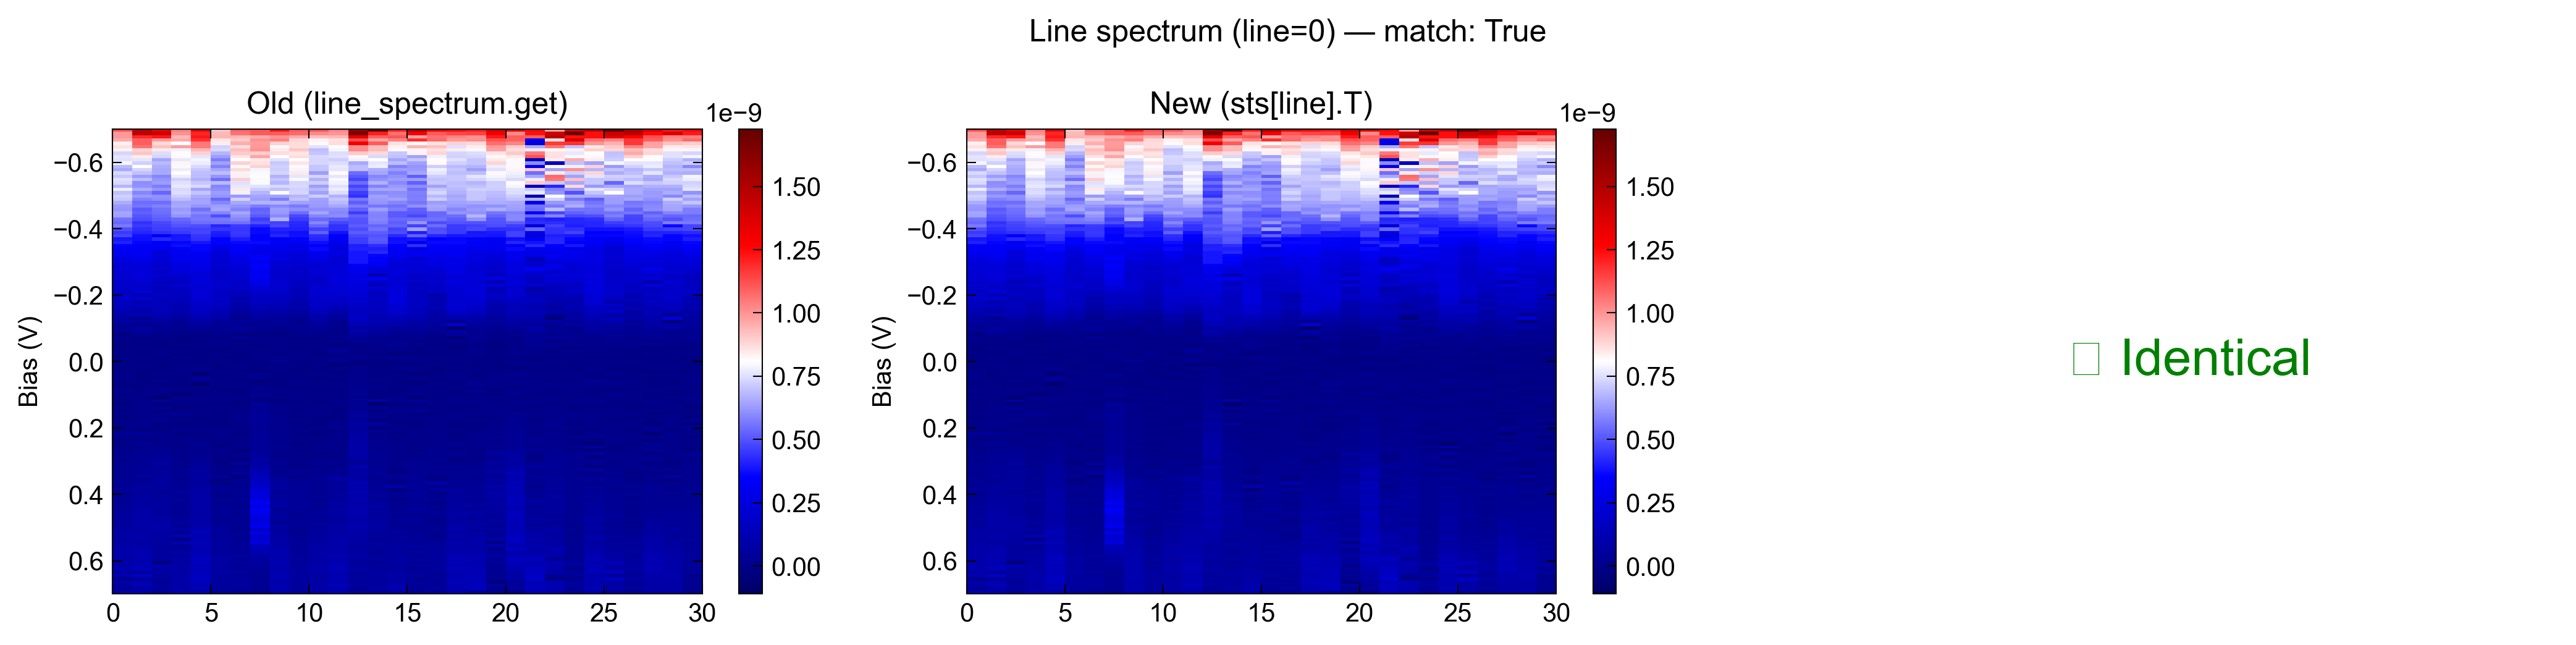

In [13]:
# 3.4 line_spectrum.get vs sts slicing
line = 0

with warnings.catch_warnings():
    warnings.simplefilter('ignore', DeprecationWarning)
    linespec_old = nr.grid.line_spectrum(d).get(line, processing='scaled')

V_new, data_3d = d.sts.scaled()
linespec_new = data_3d[line].T  # (pixels, bias) → (bias, pixels)
match = np.allclose(linespec_old, linespec_new, equal_nan=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
im0 = axes[0].imshow(linespec_old, aspect='auto', origin='upper',
                      extent=[0, linespec_old.shape[1], V_new[0], V_new[-1]], cmap=bwr())
axes[0].set_title('Old (line_spectrum.get)')
axes[0].set_ylabel('Bias (V)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(linespec_new, aspect='auto', origin='upper',
                      extent=[0, linespec_new.shape[1], V_new[0], V_new[-1]], cmap=bwr())
axes[1].set_title('New (sts[line].T)')
axes[1].set_ylabel('Bias (V)')
plt.colorbar(im1, ax=axes[1])

if not match:
    diff = np.abs(linespec_old - linespec_new)
    im2 = axes[2].imshow(diff, aspect='auto', origin='lower', cmap='hot')
    axes[2].set_title(f'|Diff| max={np.nanmax(diff):.2e}')
    plt.colorbar(im2, ax=axes[2])
else:
    axes[2].text(0.5, 0.5, '✅ Identical', transform=axes[2].transAxes,
                ha='center', va='center', fontsize=20, color='green')
    axes[2].set_axis_off()

fig.suptitle(f'Line spectrum (line={line}) — match: {match}', fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. `normalize_didv` 독립 함수

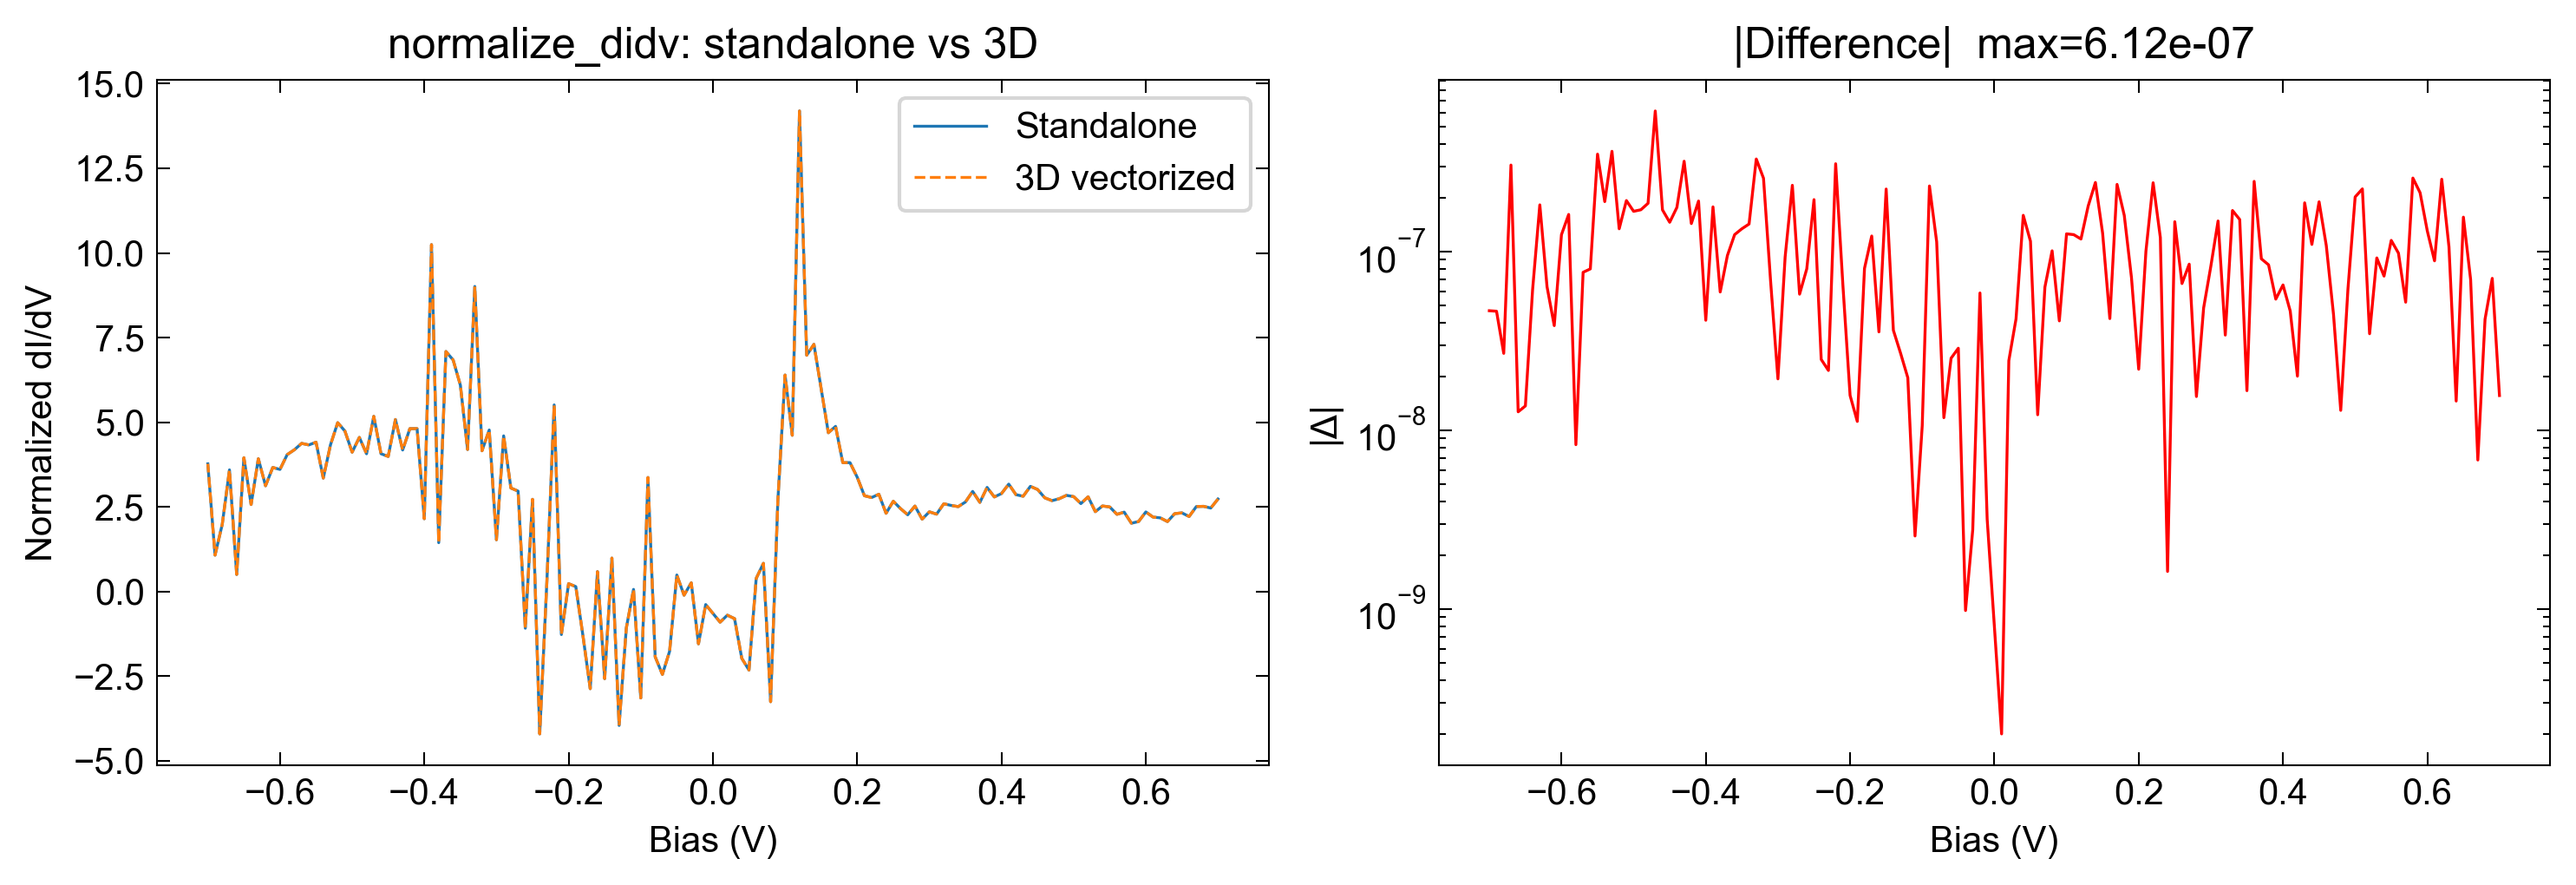

Note: Small differences are expected (per-pixel curve_fit vs vectorized polyfit)


In [19]:
# 4.1 standalone vs 3D vectorized
V, sc_3d = d.sts.scaled()
single = sc_3d[0, 0]

# Standalone
V_sa, norm_sa = nr.normalize_didv(V, single, factor=0.2, delete_zero_bias=True)

# From 3D
V_3d, norm_3d = d.sts.normalized(factor=0.2, delete_zero_bias=True)
norm_from_3d = norm_3d[0, 0]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(V_sa, norm_sa, lw=0.8, label='Standalone')
axes[0].plot(V_3d, norm_from_3d, lw=0.8, ls='--', label='3D vectorized')
axes[0].legend()
axes[0].set_title('normalize_didv: standalone vs 3D')
axes[0].set_xlabel('Bias (V)')
axes[0].set_ylabel('Normalized dI/dV')

diff = np.abs(norm_sa - norm_from_3d)
axes[1].semilogy(V_sa, diff, lw=0.8, color='red')
axes[1].set_title(f'|Difference|  max={np.nanmax(diff):.2e}')
axes[1].set_xlabel('Bias (V)')
axes[1].set_ylabel('|Δ|')

plt.tight_layout()
plt.show()

print(f'Note: Small differences are expected (per-pixel curve_fit vs vectorized polyfit)')

---
## 5. Deprecation Warning 확인

In [15]:
# 5.1 Deprecated → warning 발생
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter('always')
    _ = d.point
    dep = [x for x in w if issubclass(x.category, DeprecationWarning)]
    print(f'd.point → DeprecationWarning: {len(dep) > 0}')
    for dw in dep:
        print(f'  "{dw.message}"')

# 5.2 New API → warning 없음
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter('always')
    _ = d.sts
    V, data = d.sts.scaled()
    dep = [x for x in w if issubclass(x.category, DeprecationWarning)]
    print(f'\nd.sts → DeprecationWarning: {len(dep) > 0}  (should be False)')

d.point → DeprecationWarning: True
  "point_didv is deprecated. Use sts instead: V, data = d.sts.scaled(); data[line, pixel]"

d.sts → DeprecationWarning: False  (should be False)


---
## 6. I-z 테스트 (I-z grid 데이터가 있는 경우에만)

File: TNS_STM6_#117_3518.3ds
dim_px: [25, 25]  (pixels_x, pixels_y)
Signal keys: ['params', 'Current (A)', 'Current [bwd] (A)', 'sweep_signal', 'topo']...
Bias points: 151
Bias range: 0.000 ~ -0.000 V


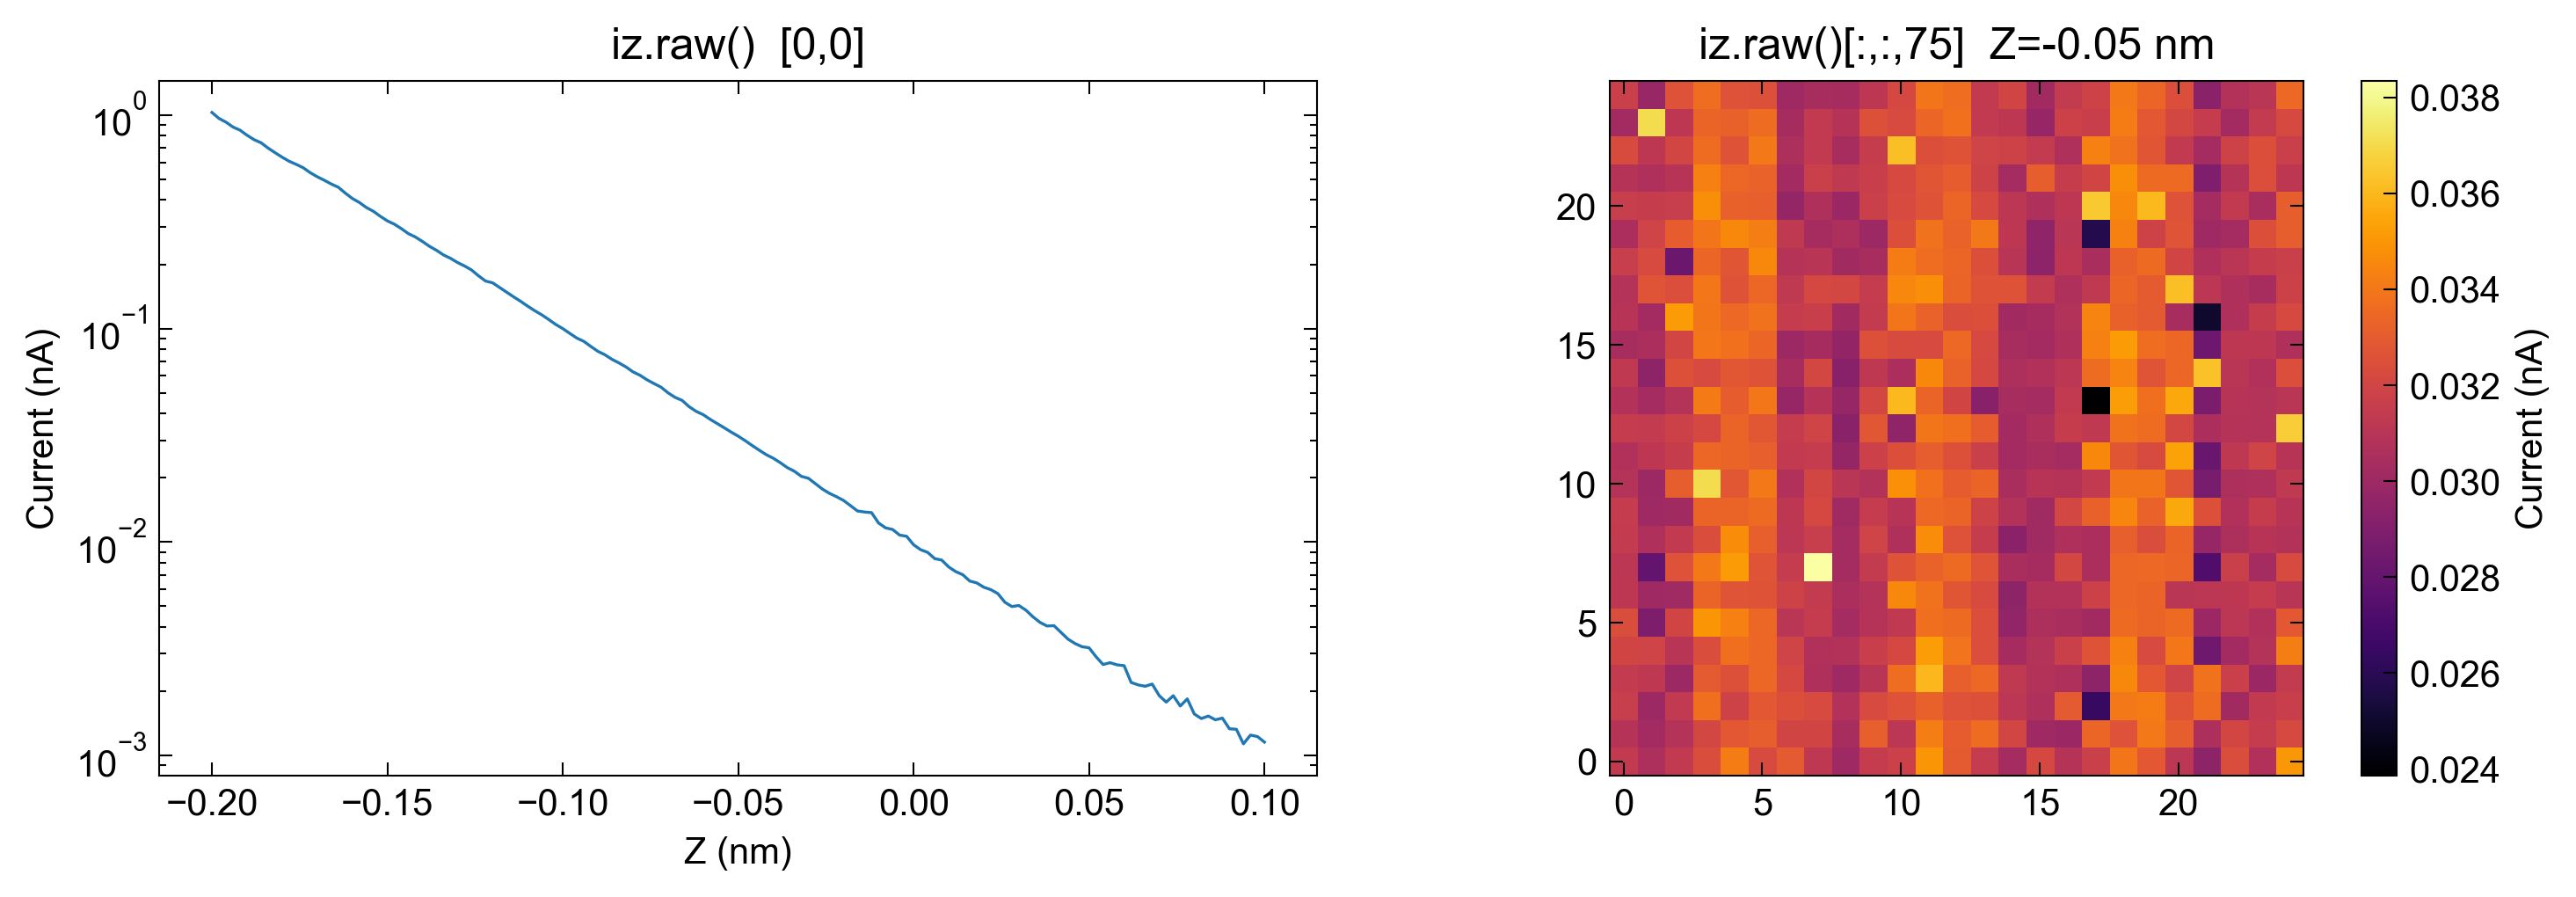

In [ ]:
# I-z 데이터가 아닌 경우 이 셀은 건너뛰세요
dd = nr.load('/Users/kim/Library/CloudStorage/OneDrive-Personal/Data/230922_TNS_STM6/TNS_STM6_#117_3518.3ds')
print(f'File: {dd.fname}')
print(f'dim_px: {dd.header["dim_px"]}  (pixels_x, pixels_y)')
print(f'Signal keys: {list(dd.signals.keys())[:8]}...')
print(f'Bias points: {len(dd.sts.sweep_signal)}')
print(f'Bias range: {dd.sts.sweep_signal[0]:.3f} ~ {dd.sts.sweep_signal[-1]:.3f} V')

try:
    Z, current_3d = dd.iz.raw()
    line, pixel = 0, 0

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

    axes[0].plot(Z * 1e9, current_3d[line, pixel] * 1e9, lw=0.8)
    axes[0].set_title(f'iz.raw()  [{line},{pixel}]')
    axes[0].set_xlabel('Z (nm)')
    axes[0].set_ylabel('Current (nA)')
    axes[0].set_yscale('log')

    mid_z = len(Z) // 2
    im = axes[1].imshow(current_3d[:, :, mid_z] * 1e9, cmap='inferno', origin='lower')
    axes[1].set_title(f'iz.raw()[:,:,{mid_z}]  Z={Z[mid_z]*1e9:.2f} nm')
    plt.colorbar(im, ax=axes[1], label='Current (nA)')

    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f'I-z test skipped: {e}')

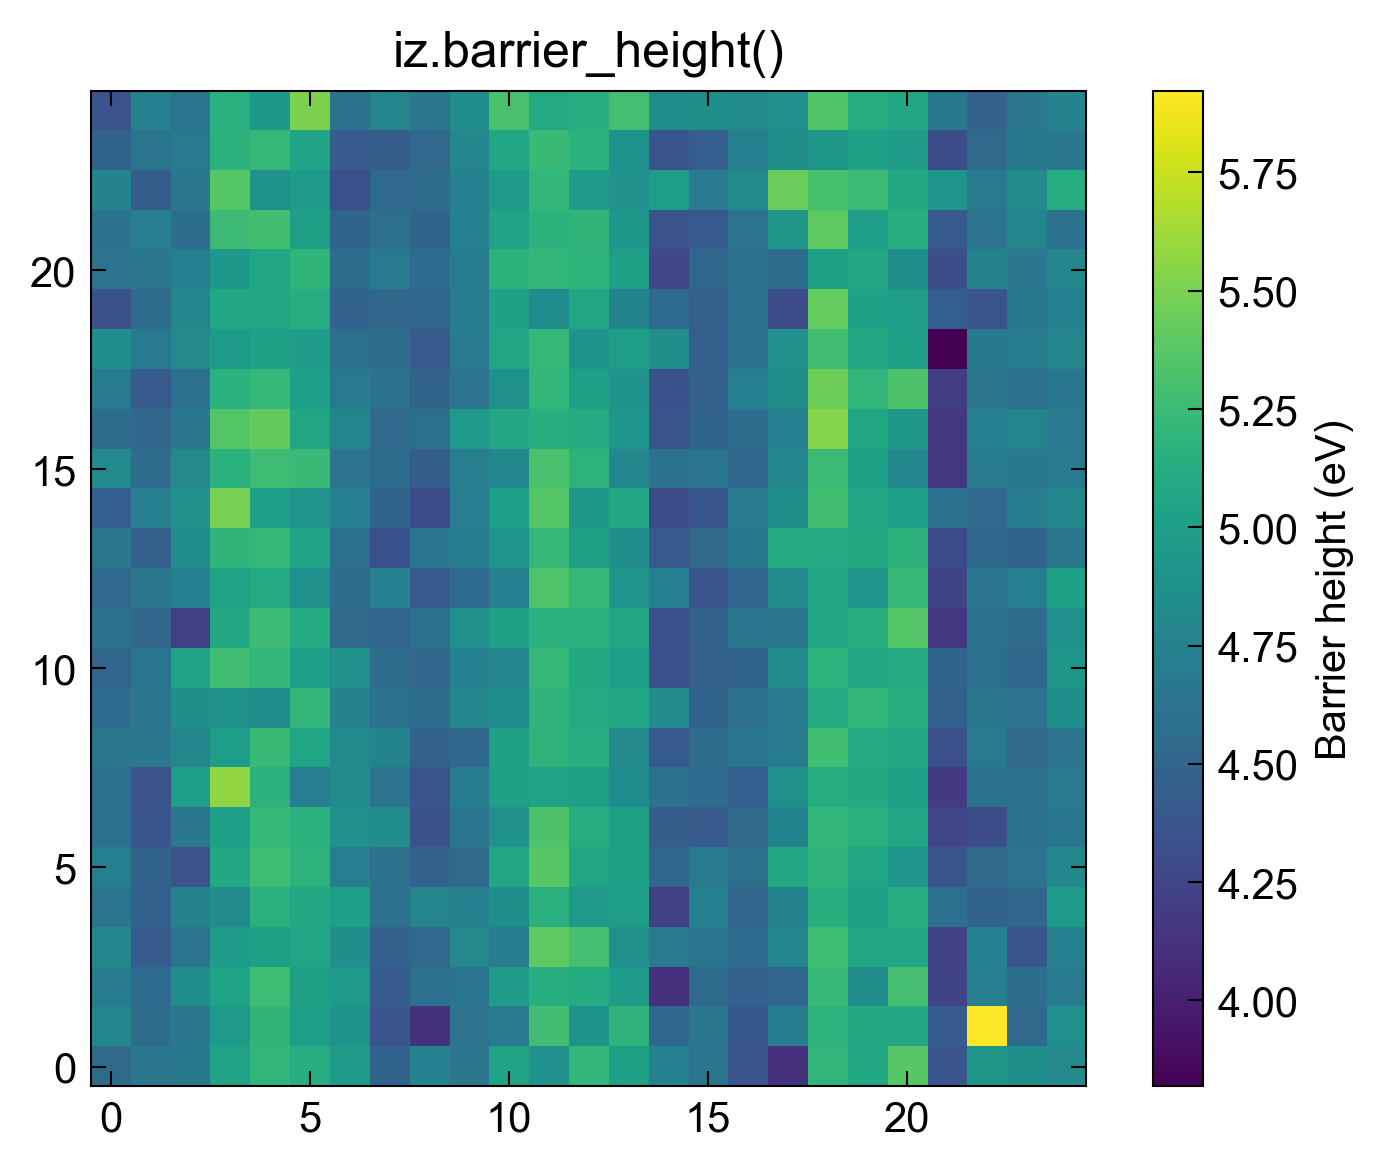

Mean: 4.808 eV


In [17]:
# Barrier height map (slow — uncomment to run)
try:
    bh = dd.iz.barrier_height(fitting_current_range=(1e-12, 10e-12))
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(bh, cmap='viridis', origin='lower')
    ax.set_title('iz.barrier_height()')
    plt.colorbar(im, ax=ax, label='Barrier height (eV)')
    plt.tight_layout()
    plt.show()
    print(f'Mean: {np.nanmean(bh):.3f} eV')
except Exception as e:
    print(f'Barrier height skipped: {e}')

In [22]:
# ⚠️ save all이 적용된 .3ds 파일 경로로 수정하세요
saveall_3ds_path = '/Users/kim/Library/CloudStorage/OneDrive-Personal/Data/230922_TNS_STM6/TNS_STM6_#117_0822.3ds'
ddd = nr.load(saveall_3ds_path)
print(f'File: {ddd.fname}')
print(f'dim_px: {ddd.header["dim_px"]}  (pixels_x, pixels_y)')
print(f'Signal keys: {list(ddd.signals.keys())[:8]}...')
print(f'Bias points: {len(ddd.sts.sweep_signal)}')
print(f'Bias range: {ddd.sts.sweep_signal[0]:.3f} ~ {ddd.sts.sweep_signal[-1]:.3f} V')

File: TNS_STM6_#117_0822.3ds
dim_px: [100, 2]  (pixels_x, pixels_y)
Signal keys: ['params', 'Current [AVG] (A)', 'LI Demod 1 X [AVG] (A)', 'Current [00001] (A)', 'LI Demod 1 X [00001] (A)', 'Current [00002] (A)', 'LI Demod 1 X [00002] (A)', 'Current [00003] (A)']...
Bias points: 201
Bias range: 1.000 ~ -1.000 V
